---
---
---

# Summary

---
---
---

<br>

> | **_Language:_** python@3.12.10 |
> | - |

<br>

> | **_Source:_** `notebook/summary.ipynb` |
> | - |

<br>

> | **_Configurations:_** `lib/config` |
> | - |

<br>

> | **_Libraries:_** `lib/utils` |
> | - |

<br>

## Dependencies

### Packages

In [1]:
from IPython.display import Image, display
from google.cloud import bigquery, storage
from loguru import logger
from paddleocr import TextRecognition
from pathlib import Path

import contextily as ctx
import cv2
import geopandas as gpd
import io
import joblib
import math
import matplotlib.pyplot as plt
import numpy as np
import paddle
import pandas as pd
import shutil
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name in ["notebook"]:
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from jobs.data_extract import extract_data
from lib import config as the_config
from lib import utils as the_utils
from lib.automl import AutoMLClassifier, AutoMLRegressor

# -------------------------

# Settings
%matplotlib inline
the_config.refresh_logging()
paddle.disable_signal_handler()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", "{:.3f}".format)
warnings.filterwarnings("ignore")

/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### Constants

In [2]:
# GCP
BQ_CLIENT = bigquery.Client(project=the_config.GCP_PROJECT)
GCS_CLIENT = storage.Client(project=the_config.GCP_PROJECT)
GCS_BUCKET = GCS_CLIENT.bucket(the_config.GCS_BUCKET)

### Paths

In [3]:
for path in the_config.PATHS:
    the_utils.ensure_path(path)

## Data Collection

### Context

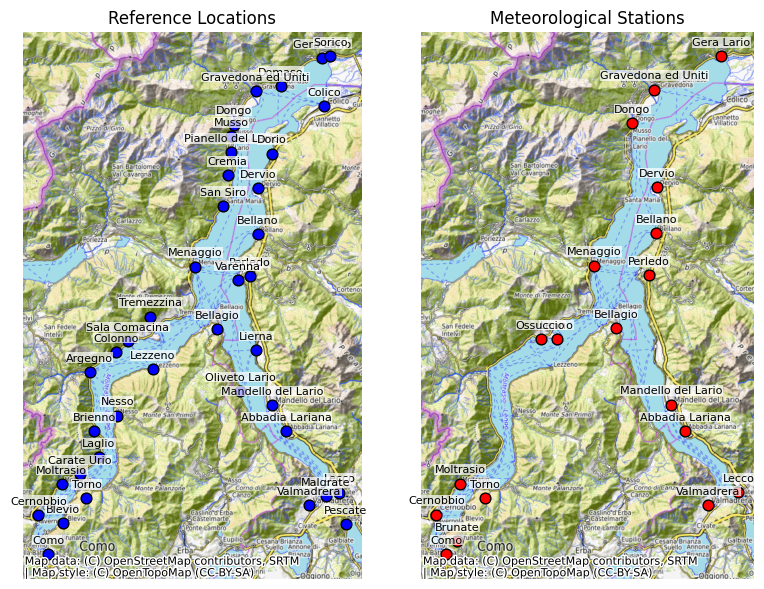

In [4]:
locations = []
for province, cities in the_config.LOCATIONS.items():
    for city_key, info in cities.items():
        locations.append({
            "name": info["city"],
            "latitude": info["latitude"],
            "longitude": info["longitude"],
        })

stations = []
for province, tags in the_config.STATIONS.items():
    for tag, info in tags.items():
        stations.append({
            "name": info["city"],
            "latitude": info["latitude"],
            "longitude": info["longitude"],
        })

locations_df = pd.DataFrame(locations)
g_locations_df = gpd.GeoDataFrame(
	locations_df,
	geometry=gpd.points_from_xy(
        locations_df.longitude,
        locations_df.latitude
    ),
	crs="EPSG:4326",
).to_crs(epsg=3857)

stations_df = pd.DataFrame(stations)
g_stations_df = gpd.GeoDataFrame(
	stations_df,
	geometry=gpd.points_from_xy(
        stations_df.longitude,
        stations_df.latitude
    ),
	crs="EPSG:4326",
).to_crs(epsg=3857)

# -------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
g_locations_df.plot(
    ax=ax1,
    color="blue",
    markersize=60,
    edgecolor="black",
)

for _, row in g_locations_df.iterrows():
    ax1.annotate(
        row["name"],
        (row.geometry.x, row.geometry.y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        bbox=dict(fc="white", alpha=0.7, ec="none", pad=0.2),
    )
ctx.add_basemap(ax1, source=ctx.providers.OpenTopoMap)
ax1.set_title("Reference Locations")
ax1.set_axis_off()

# -------------------------

g_stations_df.plot(
    ax=ax2,
    color="red",
    markersize=60,
    edgecolor="black",
)

for _, row in g_stations_df.iterrows():
    ax2.annotate(
        row["name"],
        (row.geometry.x, row.geometry.y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        bbox=dict(fc="white", alpha=0.7, ec="none", pad=0.2),
    )
ctx.add_basemap(ax2, source=ctx.providers.OpenTopoMap)
ax2.set_title("Meteorological Stations")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

### Extraction

In [5]:
extract_data(n=1)

2026-08-21 12:15:00.463 | INFO     | jobs.data_extract:extract_data:28 - 

# =========================
# (1) EXTRACTION
# =========================

2026-08-21 12:15:00.469 | DEBUG    | jobs.data_extract:extract_data:60 - [2026-08-21 @ 12:15] [01/19]
2026-08-21 12:15:00.469 | DEBUG    | jobs.data_extract:extract_data:61 - [2026-08-21 @ 12:15] STATION: Bellagio
2026-08-21 12:15:00.605 | SUCCESS  | jobs.data_extract:extract_data:88 - [2026-08-21 @ 12:15] EXTRACTED: bellagio_cernobbio-20260821-1215.png



{'bellagio_cernobbio': {'city': 'Bellagio',
  'province': 'Como',
  'latitude': 45.9746,
  'longitude': 9.2616}}

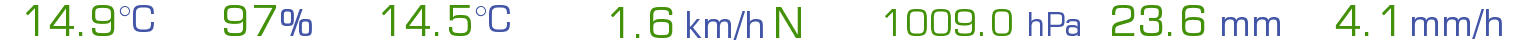

In [6]:
files = list(the_config.TMP_IMG_PATH.iterdir())
filename = files[0]
display(Image(filename=str(filename)))

### Transformation

In [7]:
# [!]
img_cv = cv2.imread(str(filename))
img_cv = cv2.resize(
    img_cv,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)
green_mask = cv2.inRange(
    hsv,
    np.array([35, 50, 50]),
    np.array([85, 255, 255]),
)
green = np.full_like(green_mask, 255)
green[green_mask > 0] = 0
blue_mask = cv2.inRange(
    hsv,
    np.array([90, 50, 50]),
    np.array([130, 255, 255]),
)
blue = np.full_like(blue_mask, 255)
blue[blue_mask > 0] = 0

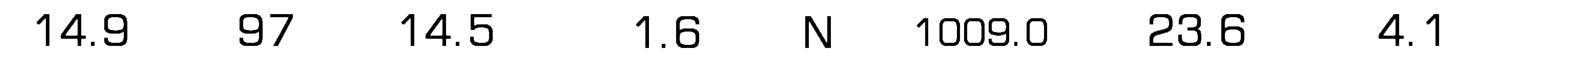

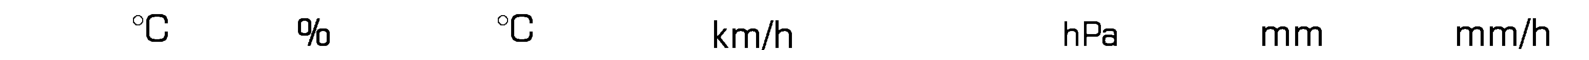

In [8]:
plt.figure(figsize=(16, 4))
plt.imshow(green, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.imshow(blue, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# [!]
green_rois = the_utils.extract_rois(img_cv, green_mask, "green")
blue_rois  = the_utils.extract_rois(img_cv, blue_mask, "blue")
all_rois = sorted(green_rois + blue_rois, key=lambda r: r["bbox"][0])

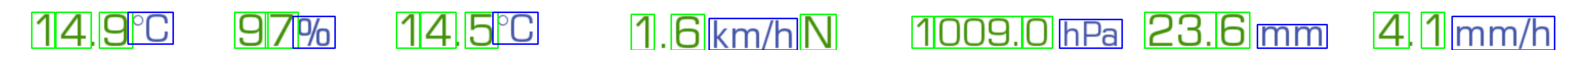

In [10]:
debug = img_cv.copy()
green_idx = 1
blue_idx = 1

for roi in all_rois:

    x1, y1, x2, y2 = roi["bbox"]
    if roi["type"] == "green":
        box_color = (0, 255, 0)
        letter = "G"
        idx = green_idx
        green_idx += 1
    else:
        box_color = (255, 0, 0)
        letter = "B"
        idx = blue_idx
        blue_idx += 1

    cv2.rectangle(debug, (x1, y1), (x2, y2), box_color, 2)
    (letter_w, letter_h), _ = cv2.getTextSize(
		letter,
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)
    (label_w, label_h), baseline = cv2.getTextSize(
		f"{letter}{idx}",
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)

plt.figure(figsize=(16, 4))
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# [!]
pieces = the_utils.get_pieces(img_cv, green_mask, all_rois)

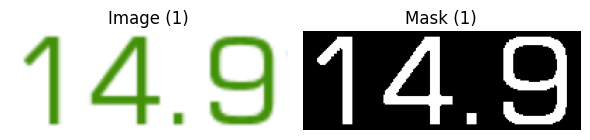

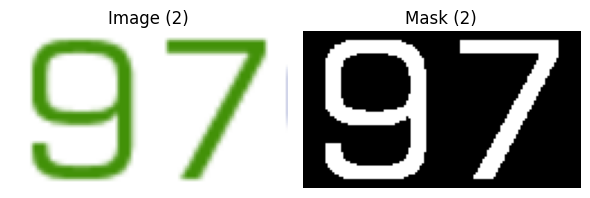

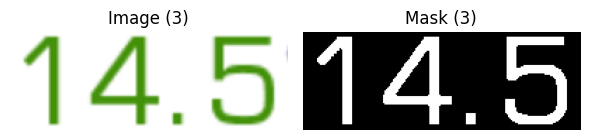

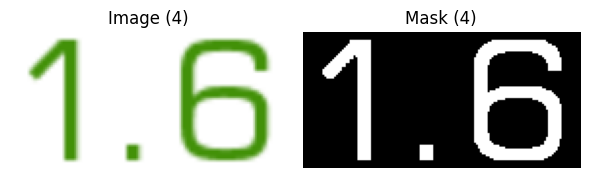

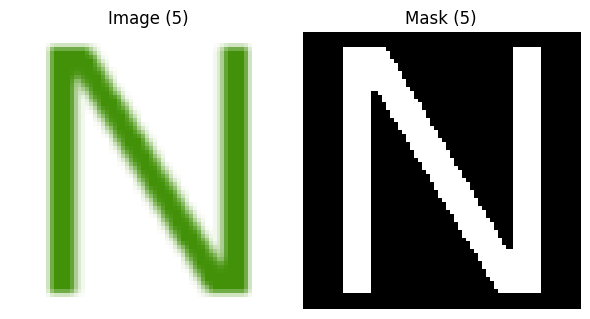

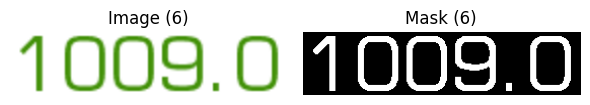

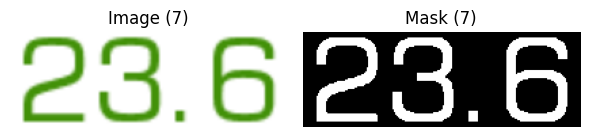

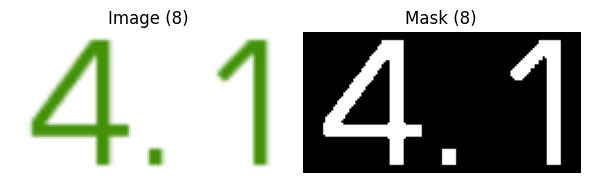

In [12]:
for i, piece in enumerate(pieces, start=1):

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))
    axes[0].imshow(cv2.cvtColor(piece["image"], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image ({i})")
    axes[0].axis("off")
    axes[1].imshow(piece["green_mask"], cmap="gray")
    axes[1].set_title(f"Mask ({i})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [13]:
# [!]
MODEL_OCR = TextRecognition(
    model_name=the_config.CV_OCR_MODEL,
    device=the_config.CV_DEVICE
)

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/robertovicario/.paddlex/official_models/PP-OCRv5_server_rec`.


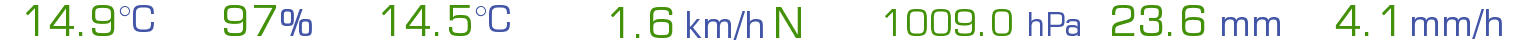

2026-08-21 12:15:02.045 | DEBUG    | lib.utils:ocr_predict:166 -  temperature_c:   14.9 (confidence=1.000)
2026-08-21 12:15:02.117 | DEBUG    | lib.utils:ocr_predict:166 -   humidity_pct:     97 (confidence=1.000)
2026-08-21 12:15:02.186 | DEBUG    | lib.utils:ocr_predict:166 -    dew_point_c:   14.5 (confidence=1.000)
2026-08-21 12:15:02.256 | DEBUG    | lib.utils:ocr_predict:166 - wind_speed_kmh:    1.6 (confidence=1.000)
2026-08-21 12:15:02.325 | DEBUG    | lib.utils:ocr_predict:166 -       wind_dir:      N (confidence=0.994)
2026-08-21 12:15:02.395 | DEBUG    | lib.utils:ocr_predict:166 -   pressure_hpa: 1009.0 (confidence=1.000)
2026-08-21 12:15:02.465 | DEBUG    | lib.utils:ocr_predict:166 -        rain_mm:   23.6 (confidence=1.000)
2026-08-21 12:15:02.541 | DEBUG    | lib.utils:ocr_predict:166 -       rain_mmh:    4.1 (confidence=0.995)


In [14]:
display(Image(filename))

# [!]
values = the_utils.ocr_predict(
    MODEL_OCR,
    the_config.CV_OCR_FIELDS,
    pieces,
    verbose=True
)

### Loading

In [15]:
query = f"""
	SELECT * FROM `{the_config.BQ_TABLE}`
	ORDER BY TIMESTAMP(
		DATETIME(year, month, day, hour, minute, 0)
	)
"""
df = BQ_CLIENT.query(query).to_dataframe()
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128649 entries, 0 to 128648
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 128649 non-null  dbdate 
 1   year                 128649 non-null  Int64  
 2   month                128649 non-null  Int64  
 3   day                  128649 non-null  Int64  
 4   hour                 128649 non-null  Int64  
 5   minute               128649 non-null  Int64  
 6   quarter              128649 non-null  Int64  
 7   week_of_year         128649 non-null  Int64  
 8   day_of_year          128649 non-null  Int64  
 9   day_of_week          128649 non-null  Int64  
 10  station              128649 non-null  object 
 11  city                 128649 non-null  object 
 12  province             128649 non-null  object 
 13  latitude             128649 non-null  float64
 14  longitude            128649 non-null  float64
 15  temperature_c    

None

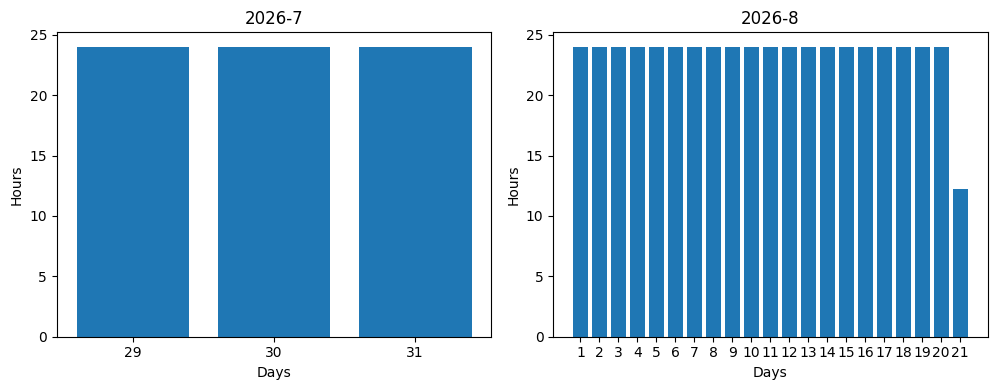

In [16]:
year_months = (
    df[["year", "month"]]
    .drop_duplicates()
    .sort_values(["year", "month"])
)
n_cols = 4
n_rows = math.ceil(len(year_months) / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()
for ax, (_, row) in zip(axes, year_months.iterrows()):

    year = row["year"]
    month = row["month"]
    counts = (
        df[(df["year"] == year) & (df["month"] == month)]
        .groupby("day")
        .size()
    )
    hours = counts / (the_config.ML_DAILY_COLL / 24)

    ax.bar(counts.index, hours.values)
    ax.set_title(f"{year}-{month}")
    ax.set_xticks(counts.index)
    ax.set_xlabel("Days")
    ax.set_ylabel("Hours")

for ax in axes[len(year_months):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
# [!]
shutil.rmtree(the_config.TMP_IMG_PATH)

## Inference

### DataFrame

In [18]:
# [!]
# DataFrame
query = f"""
	SELECT * FROM `{the_config.BQ_TABLE}`
	ORDER BY TIMESTAMP(
		DATETIME(year, month, day, hour, minute, 0)
	) DESC
	LIMIT {the_config.INF_ROWS * 2}
"""
inf_df = BQ_CLIENT.query(query).to_dataframe()
display(inf_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 912 non-null    dbdate 
 1   year                 912 non-null    Int64  
 2   month                912 non-null    Int64  
 3   day                  912 non-null    Int64  
 4   hour                 912 non-null    Int64  
 5   minute               912 non-null    Int64  
 6   quarter              912 non-null    Int64  
 7   week_of_year         912 non-null    Int64  
 8   day_of_year          912 non-null    Int64  
 9   day_of_week          912 non-null    Int64  
 10  station              912 non-null    object 
 11  city                 912 non-null    object 
 12  province             912 non-null    object 
 13  latitude             912 non-null    float64
 14  longitude            912 non-null    float64
 15  temperature_c        912 non-null    flo

None

### Feature Engineering

In [19]:
# [!]
# Feature Engineering -- Classification
clf_df, target_clf = the_utils.feature_engineering_clf(
	inf_df, inference=True
)
clf_df = clf_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)

# [!]
# Feature Selection -- Classification
to_drop = [
	*the_config.CLASSIFICATION["to_drop"],
	"timestamp"
]
to_drop += [c for c in clf_df.columns if c.lower().startswith("conf_")]
X_clf = clf_df.drop(columns=to_drop)

logger.debug(f"[LIST] Targets ({len(target_clf)}): {target_clf}")

2026-08-21 12:15:39.636 | DEBUG    | __main__:<module>:21 - [LIST] Targets (1): ['rain_flag']


In [20]:
# [!]
# Feature Engineering -- Regression
reg_df, targets_reg = the_utils.feature_engineering_reg(
	inf_df, inference=True
)
reg_df = reg_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)

# [!]
# Feature Selection -- Regression
to_drop = [
	*the_config.REGRESSION["to_drop"],
	"timestamp"
]
to_drop += [c for c in reg_df.columns if c.lower().startswith("conf_")]
X_reg = reg_df.drop(columns=to_drop)

logger.debug(f"[LIST] Targets ({len(targets_reg)}): {targets_reg}")

2026-08-21 12:15:39.788 | DEBUG    | __main__:<module>:21 - [LIST] Targets (28): ['temperature_c_lead_30', 'humidity_pct_lead_30', 'dew_point_c_lead_30', 'pressure_hpa_lead_30', 'wind_speed_kmh_lead_30', 'wind_x_lead_30', 'wind_y_lead_30', 'temperature_c_lead_60', 'humidity_pct_lead_60', 'dew_point_c_lead_60', 'pressure_hpa_lead_60', 'wind_speed_kmh_lead_60', 'wind_x_lead_60', 'wind_y_lead_60', 'temperature_c_lead_90', 'humidity_pct_lead_90', 'dew_point_c_lead_90', 'pressure_hpa_lead_90', 'wind_speed_kmh_lead_90', 'wind_x_lead_90', 'wind_y_lead_90', 'temperature_c_lead_120', 'humidity_pct_lead_120', 'dew_point_c_lead_120', 'pressure_hpa_lead_120', 'wind_speed_kmh_lead_120', 'wind_x_lead_120', 'wind_y_lead_120']


### Train-Test Split

In [21]:
# [!]
# Train-Test Split -- Classification
X_test_clf = X_clf.iloc[-the_config.INF_ROWS:]

logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Features:':<10}{X_test_clf.columns.tolist()}")
logger.debug(f"{'[TEST]':<8}{'[CLF]':<6}{'Shape:':<10}{X_test_clf.shape}")

2026-08-21 12:15:39.796 | DEBUG    | __main__:<module>:5 - [LIST]  [CLF] Features: ['latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa']
2026-08-21 12:15:39.797 | DEBUG    | __main__:<module>:6 - [TEST]  [CLF] Shape:    (456, 7)


In [22]:
# [!]
# Train-Test Split -- Regression
X_test_reg = X_reg.iloc[-the_config.INF_ROWS:]

logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Features:':<10}{X_test_reg.columns.tolist()}")
logger.debug(f"{'[TEST]':<8}{'[REG]':<6}{'Shape:':<10}{X_test_reg.shape}")

2026-08-21 12:15:39.808 | DEBUG    | __main__:<module>:5 - [LIST]  [REG] Features: ['year', 'month', 'day', 'hour', 'minute', 'quarter', 'week_of_year', 'day_of_year', 'day_of_week', 'latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa', 'wind_x', 'wind_y', 'temperature_c_lag_1', 'temperature_c_lag_2', 'temperature_c_lag_3', 'temperature_c_lag_6', 'temperature_c_lag_12', 'temperature_c_lag_18', 'temperature_c_lag_24', 'humidity_pct_lag_1', 'humidity_pct_lag_2', 'humidity_pct_lag_3', 'humidity_pct_lag_6', 'humidity_pct_lag_12', 'humidity_pct_lag_18', 'humidity_pct_lag_24', 'dew_point_c_lag_1', 'dew_point_c_lag_2', 'dew_point_c_lag_3', 'dew_point_c_lag_6', 'dew_point_c_lag_12', 'dew_point_c_lag_18', 'dew_point_c_lag_24', 'pressure_hpa_lag_1', 'pressure_hpa_lag_2', 'pressure_hpa_lag_3', 'pressure_hpa_lag_6', 'pressure_hpa_lag_12', 'pressure_hpa_lag_18', 'pressure_hpa_lag_24', 'wind_speed_kmh_lag_1', 'wind_speed_kmh_lag_2', 'wind_speed_km

### Models

In [23]:
# [!]
# Model -- Classification
clf_blob = next(
    blob for blob in GCS_BUCKET.list_blobs(
        prefix=the_config.GCS_PREFIX_LATEST
    )
    if blob.name.endswith("_classifier.joblib")
)
clf = joblib.load(
    io.BytesIO(clf_blob.download_as_bytes())
)
display(clf)

# [!]
# Model -- Regression
reg_blob = next(
    blob for blob in GCS_BUCKET.list_blobs(
        prefix=the_config.GCS_PREFIX_LATEST
    )
    if blob.name.endswith("_regressor.joblib")
)
reg = joblib.load(
    io.BytesIO(reg_blob.download_as_bytes())
)
display(reg)

### Predictions

In [24]:
# Feature Selection -- Regression
latest = (
	reg_df
	.sort_values(["station", "timestamp"])
	.groupby("station")
	.tail(1)
)
to_drop = [
	*the_config.REGRESSION["to_drop"],
	"timestamp"
]
to_drop += [c for c in reg_df.columns if c.lower().startswith("conf_")]
X_latest_reg = latest.drop(columns=[c for c in to_drop if c in latest.columns])

reg_features = getattr(next(iter(reg.model_.values())), "feature_names_in_", None)
if reg_features is not None:
	X_latest_reg = X_latest_reg[list(reg_features)]

# Prediction -- Regression
y_pred_reg = reg.predict(X_latest_reg)

# Results -- Regression
results_df = (
	y_pred_reg
	.rename_axis("row_index")
	.reset_index()
	.melt(id_vars="row_index", var_name="variable", value_name="value")
	.assign(
		lead=lambda x: x["variable"].str.extract(r"_lead_(\d+)$")[0].astype(int),
		variable=lambda x: x["variable"].str.replace(
			r"_lead_\d+$", "", regex=True
		)
	)
	.pivot(
		index=["row_index", "lead"],
		columns="variable",
		values="value"
	)
	.reset_index()
	.rename_axis(None, axis=1)
)

# -------------------------

# Feature Selection -- Classification
station = latest[
	["station", "city", "latitude", "longitude", "timestamp"]
].rename_axis("row_index").reset_index()
results_df = results_df.merge(station, on="row_index")
results_df["timestamp"] += pd.to_timedelta(results_df["lead"], unit="m")

clf_features = getattr(clf.model_, "feature_names_in_", None)
if clf_features is None:

	to_drop = [
		*the_config.CLASSIFICATION["to_drop"],
		"timestamp"
	]
	to_drop += [c for c in clf_df.columns if c.lower().startswith("conf_")]
	clf_features = (
		clf_df
		.drop(columns=[c for c in to_drop if c in clf_df.columns])
		.columns.tolist()
	)

# Prediction -- Classification
results_df["rain_proba"] = clf.predict_proba(
	results_df[list(clf_features)]
)[:, 1]

# Results -- Classification
results_df = results_df[the_config.INF_RES_COLS]
actual_df = (
	latest[the_config.INF_ACTUAL_COLS]
	.assign(
		lead=0,
		rain_proba=lambda x: x["rain_mm"].gt(0).astype(int),
	)
	.drop(columns=["rain_mm"])
)

# -------------------------

(
	pd.concat([actual_df, results_df], ignore_index=True)
	[the_config.INF_RES_COLS]
	.sort_values(["city", "station", "lead"])
	.reset_index(drop=True)
)

,timestamp,station,city,latitude,longitude,lead,temperature_c,humidity_pct,dew_point_c,pressure_hpa,wind_speed_kmh,wind_x,wind_y,rain_proba
0,2026-08-21 12:10:00,abbadia,Abbadia Lariana,45.900,9.334,0,17.600,93.000,16.400,1007.600,4.800,4.435,-1.837,1.000
1,2026-08-21 12:40:00,abbadia,Abbadia Lariana,45.900,9.334,30,17.766,90.352,16.710,1008.151,5.927,3.493,-2.534,0.003
2,2026-08-21 13:10:00,abbadia,Abbadia Lariana,45.900,9.334,60,18.845,90.905,16.705,1007.966,8.405,3.478,-3.322,0.009
3,2026-08-21 13:40:00,abbadia,Abbadia Lariana,45.900,9.334,90,18.037,92.335,16.879,1008.530,8.499,2.408,-1.168,0.315
4,2026-08-21 14:10:00,abbadia,Abbadia Lariana,45.900,9.334,120,18.620,89.188,16.870,1010.163,8.552,3.485,-1.388,0.601
5,2026-08-21 12:10:00,bellagio_cernobbio,Bellagio,45.975,9.262,0,14.900,97.000,14.500,1009.000,1.600,1.600,0.000,1.000
6,2026-08-21 12:40:00,bellagio_cernobbio,Bellagio,45.975,9.262,30,17.401,94.147,14.423,1009.236,2.140,1.356,0.041,0.044
7,2026-08-21 13:10:00,bellagio_cernobbio,Bellagio,45.975,9.262,60,15.903,95.528,14.852,1009.085,2.264,0.610,0.196,0.001
8,2026-08-21 13:40:00,bellagio_cernobbio,Bellagio,45.975,9.262,90,17.622,94.092,14.856,1009.326,3.131,0.693,0.123,0.031
9,2026-08-21 14:10:00,bellagio_cernobbio,Bellagio,45.975,9.262,120,18.115,91.634,15.312,1010.644,2.730,0.661,-0.182,0.963
